In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [67]:
df = pd.read_csv("credit_card_default.csv")
df = df.drop(columns=['Unnamed: 0'])

In [14]:
print("=" * 55)
print("         DATASET OVERVIEW")
print("=" * 55)
print(f"Shape       : {df.shape}")
print(f"Default     : {df['default_payment_next_month'].sum()} rows")
print(f"No Default  : {(df['default_payment_next_month']==0).sum()} rows")
print(f"Default Rate: {df['default_payment_next_month'].mean():.2%}")

         DATASET OVERVIEW
Shape       : (30000, 24)
Default     : 6636 rows
No Default  : 23364 rows
Default Rate: 22.12%


In [68]:
df = df.rename(columns={'default_payment_next_month': 'default'})

df["age"] = df["age"].fillna(df["age"].median())

df["sex"] = df["sex"].fillna(df["sex"].mode()[0])
df["education"] = df["education"].fillna(df["education"].mode()[0])
df["marriage"] = df["marriage"].fillna(df["marriage"].mode()[0])
print(df.isnull().sum())

limit_bal               0
sex                     0
education               0
marriage                0
age                     0
payment_status_sep      0
payment_status_aug      0
payment_status_jul      0
payment_status_jun      0
payment_status_may      0
payment_status_apr      0
bill_statement_sep      0
bill_statement_aug      0
bill_statement_jul      0
bill_statement_jun      0
bill_statement_may      0
bill_statement_apr      0
previous_payment_sep    0
previous_payment_aug    0
previous_payment_jul    0
previous_payment_jun    0
previous_payment_may    0
previous_payment_apr    0
default                 0
dtype: int64


In [69]:
df = pd.get_dummies(df, drop_first = True)

X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [70]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [56]:
print("=" * 55)
print("         DATASET OVERVIEW")
print("=" * 55)
print(f"Shape       : {df.shape}")
print(f"Default     : {df['default'].sum()} rows")
print(f"No Default  : {(df['default']==0).sum()} rows")
print(f"Default Rate: {df['default'].mean():.2%}")

         DATASET OVERVIEW
Shape       : (30000, 73)
Default     : 6636 rows
No Default  : 23364 rows
Default Rate: 22.12%


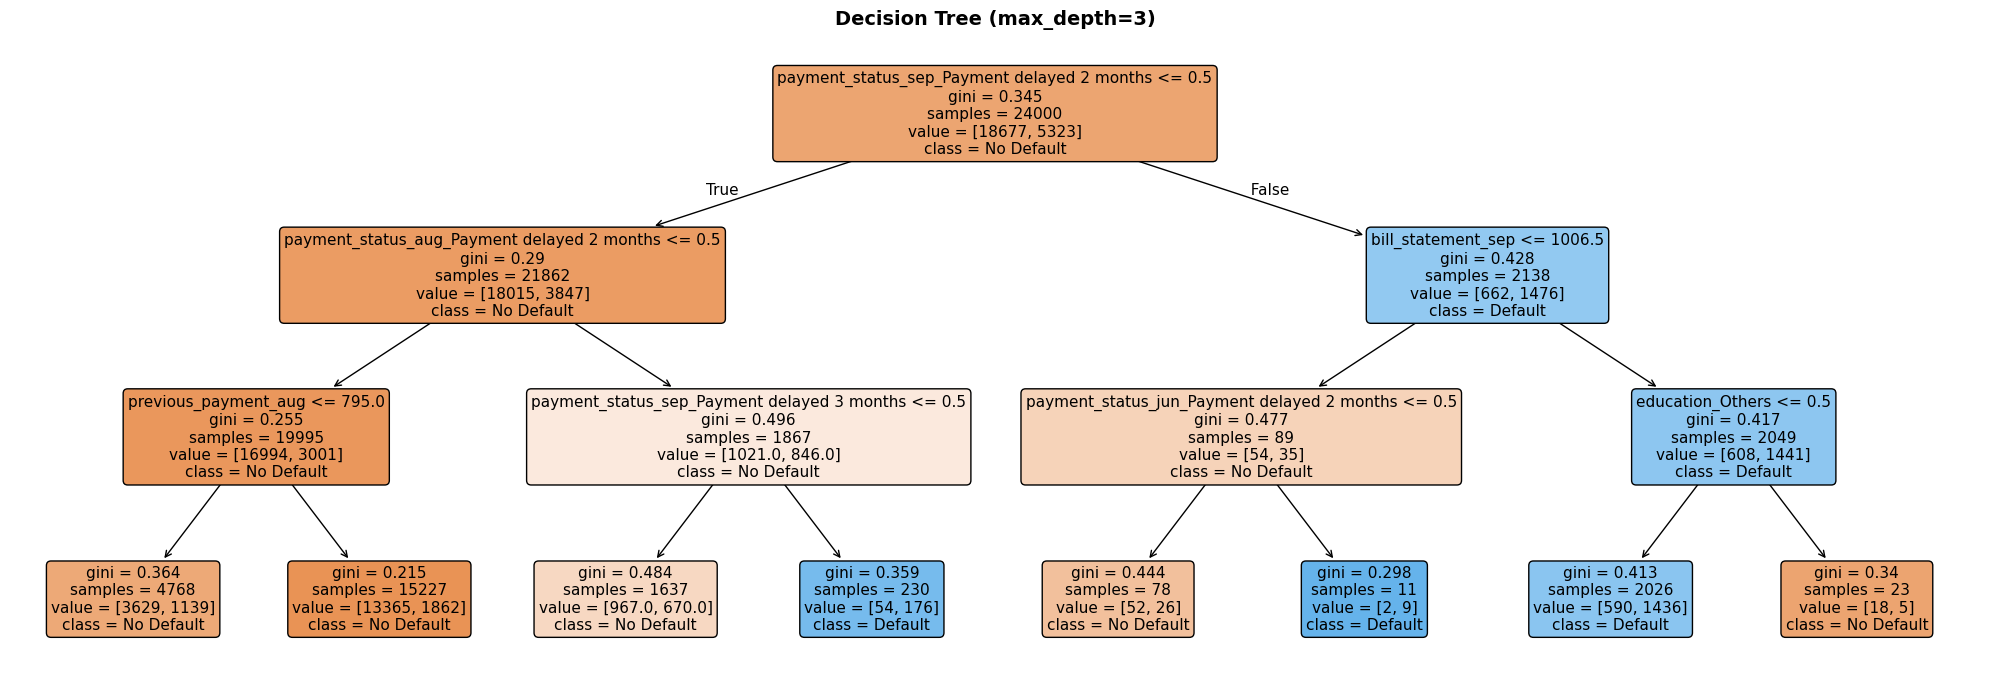

Root Node: payment_status_sep_Payment delayed 2 months


In [71]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

plt.figure(figsize=(20, 7))
plot_tree(dt,
          feature_names=X.columns,
          class_names=['No Default', 'Default'],
          filled=True, rounded=True, fontsize=11)
plt.title("Decision Tree (max_depth=3)", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("Root Node:", X.columns[dt.tree_.feature[0]])

The root node of the decision tree is payment_status_sep_payment delayed 2 months, which indicates that the most important factor influencing a customer's default behavior is their recent payment status. Specifically, customers who have delayed their payments by two months are more likely to default. This shows that recent financial behavior is a strong predictor of customer loyalty.

In [72]:
y_pred_dt = dt.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt)
dt_rec = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
print("=" * 55)
print("Accuracy: ", dt_acc)
print("Precision: ", dt_prec)
print("Recall Score: ", dt_rec)
print("F1 Score: ", dt_f1)
print("=" * 55)


Accuracy:  0.8188333333333333
Precision:  0.7077205882352942
Recall Score:  0.2932216298552932
F1 Score:  0.4146472805600431


In [73]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


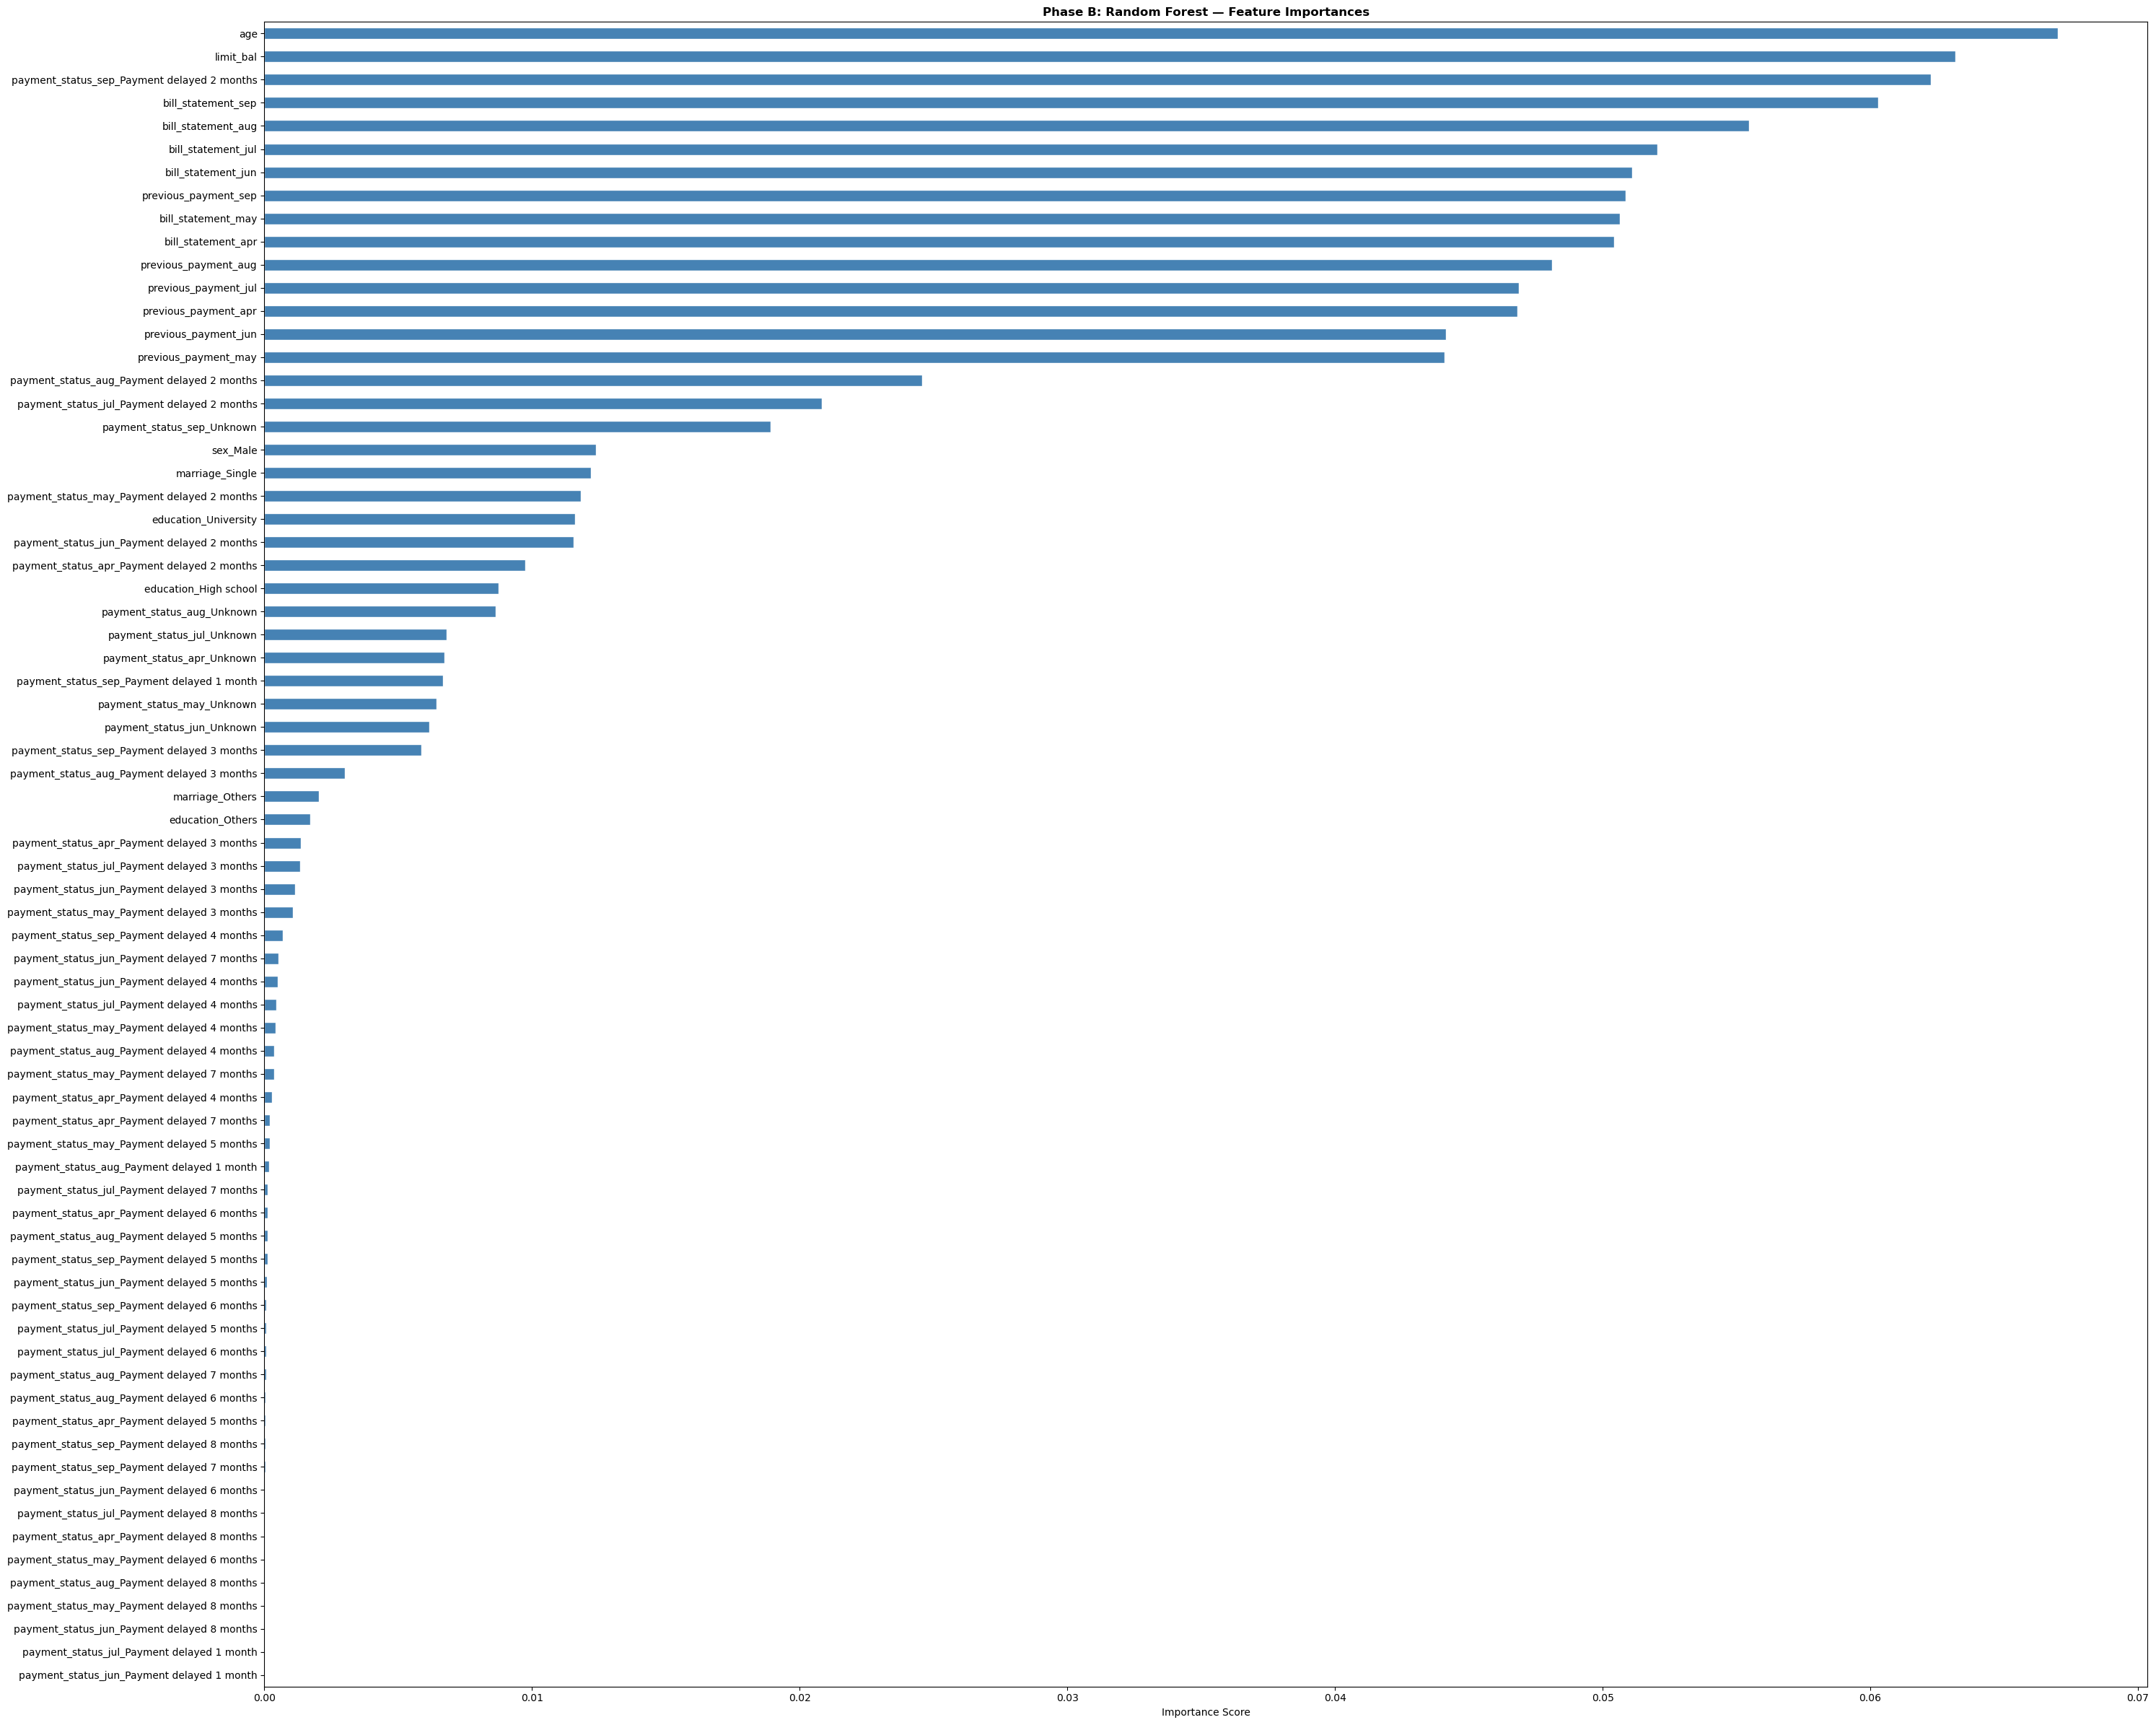

Most important feature (RF): age


In [84]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
features = X.columns

plt.figure(figsize=(30, 24))

importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title("Phase B: Random Forest — Feature Importances", fontweight='bold')
plt.xlabel("Importance Score")
plt.tight_layout()

plt.show()

print("Most important feature (RF):", importances.idxmax())

No, the Random Forest does not fully agree with the Decision Tree. The Decision Tree selects payment_status_sep_payment delayed 2 months, as the most important feature since it is used at the root node, meaning it provides the best split for that specific tree. Whereas the Random Forest identifies <b>Age</b> as the most important feature based on the average importance calculated across multiple trees. This difference arises because Random Forest reduces bias by combining many trees and provides a more generalized measure of feature importance, whereas a single Decision Tree may focus on a locally optimal feature.

In [75]:
y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf)
rf_rec = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("=" * 55)
print("Accuracy: ", rf_acc)
print("Precision: ", rf_prec)
print("Recall Score: ", rf_rec)
print("F1 Score: ", rf_f1)
print("=" * 55)

Accuracy:  0.8161666666666667
Precision:  0.6430517711171662
Recall Score:  0.3594821020563595
F1 Score:  0.46116267708842207


In [76]:
svm_low = SVC(kernel='rbf', C=0.1)
svm_low.fit(X_train_sc, y_train)

y_pred_svm_low = svm_low.predict(X_test_sc)

In [77]:
svm_low_acc = accuracy_score(y_test, y_pred_svm_low)
svm_low_prec = precision_score(y_test, y_pred_svm_low)
svm_low_rec = recall_score(y_test, y_pred_svm_low)
svm_low_f1 = f1_score(y_test, y_pred_svm_low)

print("=" * 55)
print("Accuracy: ", svm_low_acc)
print("Precision: ", svm_low_prec)
print("Recall Score: ", svm_low_rec)
print("F1 Score: ", svm_low_f1)
print("=" * 55)

Accuracy:  0.8161666666666667
Precision:  0.6822916666666666
Recall Score:  0.2993145468392993
F1 Score:  0.41609317098994175


In [81]:
svm_high = SVC(kernel='rbf', C=100)
svm_high.fit(X_train_sc, y_train)

y_pred_svm_high = svm_high.predict(X_test_sc)

In [82]:
svm_high_acc = accuracy_score(y_test, y_pred_svm_high)
svm_high_prec = precision_score(y_test, y_pred_svm_high)
svm_high_rec = recall_score(y_test, y_pred_svm_high)
svm_high_f1 = f1_score(y_test, y_pred_svm_high)

print("=" * 55)
print("Accuracy: ", svm_high_acc)
print("Precision: ", svm_high_prec)
print("Recall Score: ", svm_high_rec)
print("F1 Score: ", svm_high_f1)
print("=" * 55)

Accuracy:  0.8096666666666666
Precision:  0.6144578313253012
Recall Score:  0.3495811119573496
F1 Score:  0.44563106796116503


In [78]:
svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_train_sc, y_train)
y_pred_linear = svm_linear.predict(X_test_sc)

svm_linear_acc = accuracy_score(y_test, y_pred_linear)
svm_linear_prec = precision_score(y_test, y_pred_linear)
svm_linear_rec = recall_score(y_test, y_pred_linear)
svm_linear_f1 = f1_score(y_test, y_pred_linear)

print("=" * 55)
print("Accuracy: ", svm_linear_acc)
print("Precision: ", svm_linear_prec)
print("Recall Score: ", svm_linear_rec)
print("F1 Score: ", svm_linear_f1)
print("=" * 55)

Accuracy:  0.8188333333333333
Precision:  0.6870860927152318
Recall Score:  0.31607006854531605
F1 Score:  0.4329681794470527


A high value of C in SVM increases training accuracy because the model penalizes misclassification more strongly and tries to correctly classify all training samples by creating a more complex decision boundary. However, this can lead to overfitting, where the model captures noise in the training data and fails to generalize well to unseen data, resulting in lower testing accuracy.

In [86]:
results = {
    "Model": [
        "Decision Tree",
        "Random Forest",
        "SVM (C = 0.1)",
        "SVM (C = 100)",
        "SVM (Linear)"
    ],
    "Accuracy": [
        dt_acc,
        rf_acc,
        svm_low_acc,
        svm_high_acc,
        svm_linear_acc
    ],
    "Precision (Class 1)": [
        dt_prec,
        rf_prec,
        svm_low_prec,
        svm_high_prec,
        svm_linear_prec
    ],
    "Recall (Class 1)": [
        dt_rec,
        rf_rec,
        svm_low_rec,
        svm_high_rec,
        svm_linear_rec
    ],
    "F1-Score": [
        dt_f1,
        rf_f1,
        svm_low_f1,
        svm_high_f1,
        svm_linear_f1
    ]
}

df_results = pd.DataFrame(results)

print(df_results)

           Model  Accuracy  Precision (Class 1)  Recall (Class 1)  F1-Score
0  Decision Tree  0.818833             0.707721          0.293222  0.414647
1  Random Forest  0.816167             0.643052          0.359482  0.461163
2  SVM (C = 0.1)  0.816167             0.682292          0.299315  0.416093
3  SVM (C = 100)  0.809667             0.614458          0.349581  0.445631
4   SVM (Linear)  0.818833             0.687086          0.316070  0.432968


<b>Lab Report Discussion Questions</b>

1.	Interpretability vs. Power: If you had to explain to a Bank Manager why a specific customer was denied credit, which model's output would be easiest to use? Why? <br>

  The Decision Tree would be easiest to use for explaining why a customer was denied credit. This is because it provides a clear sequence of rules: you can trace the path from the root to the leaf node and show exactly which features and thresholds led to the decision. While models like Random Forest or SVM may be more accurate, their predictions are less transparent and harder to explain to a non-technical manager.
  
2.	The Margin Logic: In your SVM model, explain what the "Support Vectors" represent in the context of bank customers. (Are they the "average" customers or the "borderline" ones?) <br>

   In the SVM model, support vectors are the customers that lie closest to the decision boundary between the classes (e.g., likely to default vs. unlikely to default). These are the “borderline” customers, not the average ones. They are critical because the SVM uses them to define the maximum-margin hyperplane, which separates the two classes most effectively.
  
3.	Ensemble Stability: Why did the Random Forest likely achieve a higher Test Accuracy than the single Decision Tree?<br>

  A Random Forest likely achieves higher test accuracy than a single Decision Tree because it is an ensemble of multiple trees trained on different subsets of data and features. This process reduces overfitting by averaging the predictions of many trees, making the model more robust and stable. In contrast, a single Decision Tree tends to overfit the training data, capturing noise and specific patterns that do not generalize well to unseen data. Therefore, Random Forest improves generalization and typically performs better on test data.
